# AI Pulse -- Gold Analysis & Manual Review

## 1. Scope and collection limitation

This notebook analyzes only the Hacker News stories `collector.py` captured via the Algolia search API, matching `config.BROAD_KEYWORDS` and `config.TRACKED_KEYWORDS` in title/text, collected by **manual** `--backfill`/incremental runs (no continuous scheduler in this MVP). Results describe the discourse in **this collected sample of HN stories**, not all of Hacker News or the wider AI-news landscape. `points`/`num_comments` reported below are HN **engagement** counts only -- this notebook never treats them as a sentiment or view-count signal.

In [1]:
import config
import pandas as pd
from db import connect, migrate

conn = connect(config.DB_PATH)
migrate(conn)

print("DB_PATH:", config.DB_PATH)
print("BROAD_KEYWORDS:", config.BROAD_KEYWORDS)
print("TRACKED_KEYWORDS:", config.TRACKED_KEYWORDS)

coverage = pd.read_sql_query(
    "SELECT MIN(created_at) AS earliest, MAX(created_at) AS latest, "
    "COUNT(*) AS story_count FROM stories",
    conn,
)
coverage

DB_PATH: ai_monitor.db
BROAD_KEYWORDS: ['artificial intelligence', 'LLM', 'machine learning', 'AI agent']
TRACKED_KEYWORDS: ['GPT', 'Claude', 'Gemini', 'DeepSeek', 'Qwen', 'Kimi', 'Moonshot AI', 'GLM-4', 'Zhipu AI', 'ERNIE Bot', 'Baidu ERNIE', 'Doubao', 'Hunyuan', 'MiniMax', 'Baichuan', 'Yi-Large', '01.AI']


,earliest,latest,story_count
0,2026-01-17T02:41:53Z,2026-07-16T02:17:31Z,7967


## 2. Version metadata

Every Gold result below carries `collection_query_version`, `prompt_version`, `catalog_version`, and `as_of`, so each figure traces back to the exact collector query, extraction prompt, and reference-data snapshot that produced it. `AS_OF` is pinned to the latest collected story's timestamp (not wall-clock `now()`), so re-running this notebook against the same database reproduces the same windows and figures.

In [2]:
as_of_row = pd.read_sql_query("SELECT MAX(created_at) AS as_of FROM stories", conn).iloc[0]
AS_OF = as_of_row["as_of"] or "2026-07-14T00:00:00Z"  # fallback for an empty database

catalog_versions = pd.read_sql_query(
    "SELECT DISTINCT catalog_version FROM model_catalog", conn
)["catalog_version"].tolist()

print("AS_OF:", AS_OF)
print("config.PROMPT_VERSION:", config.PROMPT_VERSION)
print("config.COLLECTION_QUERY_VERSION:", config.COLLECTION_QUERY_VERSION)
print("model_catalog catalog_version(s) present:", catalog_versions)

AS_OF: 2026-07-16T02:17:31Z
config.PROMPT_VERSION: schema-free-v2
config.COLLECTION_QUERY_VERSION: v1
model_catalog catalog_version(s) present: ['2026-07-16b']


## 3. Dataset counts and the two Gold paths

Two independent paths feed the figures below, and it matters which one a figure rests on.

- **Candidate path** (Sections 4-6): `candidate_selection.py` matches every collected story against the versioned catalog aliases, offline and deterministically. It reads no LLM output, so trend and co-occurrence cover the **whole collection**.
- **Extraction path** (Sections 7-9): session-authored Silver extractions. Only these carry `stance`, so framing and the manual review rest on the **extracted sample only**, not the full collection.

The counts below show how far apart those two denominators are — read every framing figure against the extraction count, not the story count.

In [3]:
from db import catalog_version, latest_successful_extractions

story_count = pd.read_sql_query("SELECT COUNT(*) AS n FROM stories", conn).iloc[0]["n"]
extraction_status_counts = pd.read_sql_query(
    "SELECT status, COUNT(*) AS n FROM story_extractions GROUP BY status", conn
)
latest_success = latest_successful_extractions(conn)

CATALOG_VERSION = catalog_version(conn)
candidate_count = pd.read_sql_query(
    "SELECT COUNT(*) AS n FROM story_candidates WHERE catalog_version = ?",
    conn,
    params=(CATALOG_VERSION,),
).iloc[0]["n"]

print("Total collected stories:", story_count)
print(f"Candidate stories (catalog {CATALOG_VERSION}):", candidate_count)
print("Stories with a latest successful extraction:", len(latest_success))
print(f"  -> trend/co-occurrence rest on {candidate_count} stories,"
      f" framing/review on {len(latest_success)}")
extraction_status_counts

Total collected stories: 7967
Candidate stories (catalog 2026-07-16b): 2863
Stories with a latest successful extraction: 70
  -> trend/co-occurrence rest on 2863 stories, framing/review on 70


,status,n
0,succeeded,140


## 4. Family trend (`candidate_emerging_models`, `group_level="family"`)

Mention counts are per distinct story (a family mentioned twice in one story counts once). `mention_delta`/`mention_growth` compare the most recent window to the prior window of equal length; `points_sum`/`comments_sum` are engagement totals shown as context only -- they are not part of the ranking.

This runs on the **candidate path**, so it covers every collected story rather than the extracted sample. That is not only for coverage: the extraction sample is drawn by a fixed seed across the whole collection, so it scatters across months and leaves the 24-hour window nearly empty. A trend needs density in the recent window, which only the full candidate set provides.

In [4]:
from analysis import candidate_emerging_models

family_trend = candidate_emerging_models(conn, as_of=AS_OF, group_level="family")
family_trend

,vendor,family,version,resolution_status,group_label,recent_story_count,previous_story_count,mention_delta,mention_growth,points_sum,comments_sum,as_of,collection_query_version,catalog_version,candidate_reason
0,OpenAI,GPT,None,resolved,OpenAI/GPT,20,21,-1,-0.047619,172,35,2026-07-16T02:17:31Z,v1,2026-07-16b,catalog_alias_match
1,Google,Gemini,None,resolved,Google/Gemini,4,6,-2,-0.333333,11,4,2026-07-16T02:17:31Z,v1,2026-07-16b,catalog_alias_match
2,Anthropic,Claude,None,resolved,Anthropic/Claude,29,37,-8,-0.216216,856,415,2026-07-16T02:17:31Z,v1,2026-07-16b,catalog_alias_match


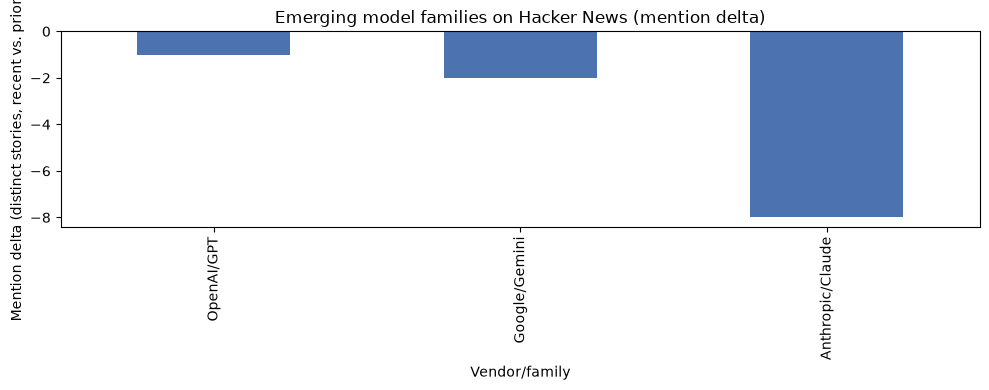

In [5]:
import matplotlib.pyplot as plt

if not family_trend.empty:
    ax = family_trend.set_index("group_label")["mention_delta"].plot(
        kind="bar", figsize=(10, 4), color="#4C72B0"
    )
    ax.set_ylabel("Mention delta (distinct stories, recent vs. prior window)")
    ax.set_xlabel("Vendor/family")
    ax.set_title("Emerging model families on Hacker News (mention delta)")
    plt.tight_layout()
    plt.show()
else:
    print("No family-level mentions in the current window/thresholds.")

## 5. Version trend (`candidate_emerging_models`, `group_level="version"`)

Same computation as Section 4, one level more specific: mentions without a resolved version are labeled `"unresolved version"` rather than dropped.

Expect most rows to be unresolved here. Version aliases (`Claude Opus 4.6`, `Gemini 2.0 Flash`, ...) attach to their **family** record in the catalog, because a version record requires a sourced release and many surfaces name rumored or unreleased versions. Version-level trend therefore stays thin until those records exist.

In [6]:
version_trend = candidate_emerging_models(conn, as_of=AS_OF, group_level="version")
version_trend

,vendor,family,version,resolution_status,group_label,recent_story_count,previous_story_count,mention_delta,mention_growth,points_sum,comments_sum,as_of,collection_query_version,catalog_version,candidate_reason
0,OpenAI,GPT,unresolved version,resolved,OpenAI/GPT/unresolved version,20,21,-1,-0.047619,172,35,2026-07-16T02:17:31Z,v1,2026-07-16b,catalog_alias_match
1,OpenAI,GPT,5.6 Sol,resolved,OpenAI/GPT/5.6 Sol,3,4,-1,-0.250000,8,2,2026-07-16T02:17:31Z,v1,2026-07-16b,catalog_alias_match
2,Google,Gemini,unresolved version,resolved,Google/Gemini/unresolved version,4,6,-2,-0.333333,11,4,2026-07-16T02:17:31Z,v1,2026-07-16b,catalog_alias_match
3,Anthropic,Claude,unresolved version,resolved,Anthropic/Claude/unresolved version,29,37,-8,-0.216216,856,415,2026-07-16T02:17:31Z,v1,2026-07-16b,catalog_alias_match


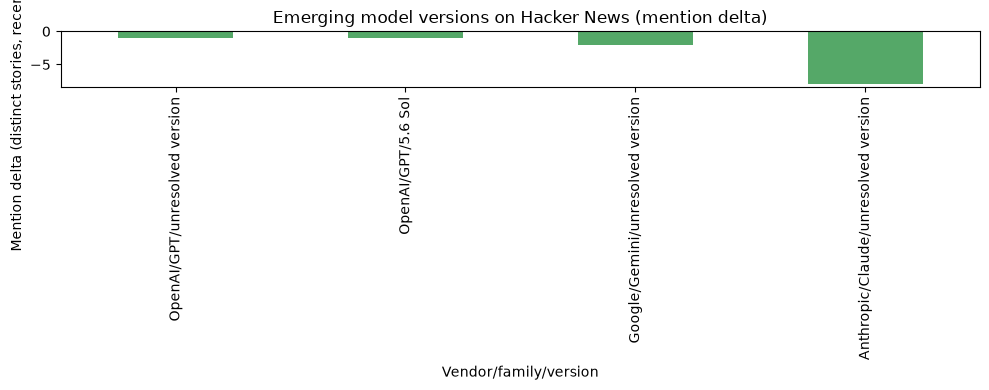

In [7]:
if not version_trend.empty:
    ax = version_trend.set_index("group_label")["mention_delta"].plot(
        kind="bar", figsize=(10, 4), color="#55A868"
    )
    ax.set_ylabel("Mention delta (distinct stories, recent vs. prior window)")
    ax.set_xlabel("Vendor/family/version")
    ax.set_title("Emerging model versions on Hacker News (mention delta)")
    plt.tight_layout()
    plt.show()
else:
    print("No version-level mentions in the current window/thresholds.")

## 6. Model co-occurrence

Pairs of distinct, resolved model families mentioned in the same story (counted once per story pair), visualized as an undirected graph where edge width is the shared-story count.

Also on the **candidate path**, so every collected story contributes. Candidate mentions are all catalog-resolved by construction, so no `unresolved` pairs appear here.

In [8]:
from analysis import candidate_model_cooccurrence

cooccurrence = candidate_model_cooccurrence(conn, as_of=AS_OF, group_level="family")
cooccurrence

,vendor_a,family_a,version_a,vendor_b,family_b,version_b,story_count,as_of,collection_query_version,catalog_version,candidate_reason
0,Anthropic,Claude,None,DeepSeek,DeepSeek,None,73,2026-07-16T02:17:31Z,v1,2026-07-16b,catalog_alias_match
1,Anthropic,Claude,None,Google,Gemini,None,405,2026-07-16T02:17:31Z,v1,2026-07-16b,catalog_alias_match
2,Anthropic,Claude,None,OpenAI,GPT,None,589,2026-07-16T02:17:31Z,v1,2026-07-16b,catalog_alias_match
3,DeepSeek,DeepSeek,None,Google,Gemini,None,46,2026-07-16T02:17:31Z,v1,2026-07-16b,catalog_alias_match
4,DeepSeek,DeepSeek,None,OpenAI,GPT,None,46,2026-07-16T02:17:31Z,v1,2026-07-16b,catalog_alias_match
5,Google,Gemini,None,OpenAI,GPT,None,341,2026-07-16T02:17:31Z,v1,2026-07-16b,catalog_alias_match
6,Anthropic,Claude,None,MiniMax,MiniMax,None,14,2026-07-16T02:17:31Z,v1,2026-07-16b,catalog_alias_match
7,Anthropic,Claude,None,Zhipu AI,GLM,None,42,2026-07-16T02:17:31Z,v1,2026-07-16b,catalog_alias_match
8,MiniMax,MiniMax,None,Zhipu AI,GLM,None,16,2026-07-16T02:17:31Z,v1,2026-07-16b,catalog_alias_match
9,Alibaba,Qwen,None,DeepSeek,DeepSeek,None,20,2026-07-16T02:17:31Z,v1,2026-07-16b,catalog_alias_match


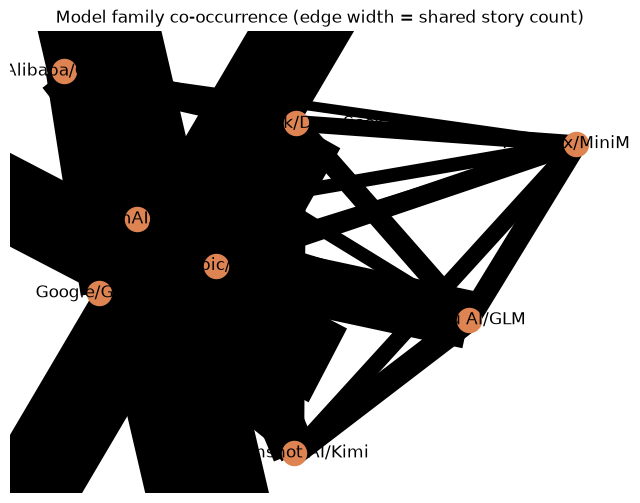

In [9]:
import networkx as nx

if not cooccurrence.empty:
    graph = nx.Graph()
    for _, row in cooccurrence.iterrows():
        label_a = f"{row['vendor_a']}/{row['family_a']}"
        label_b = f"{row['vendor_b']}/{row['family_b']}"
        graph.add_edge(label_a, label_b, weight=row["story_count"])

    pos = nx.spring_layout(graph, seed=20260714)
    weights = [graph[u][v]["weight"] for u, v in graph.edges()]
    plt.figure(figsize=(8, 6))
    nx.draw_networkx(graph, pos, with_labels=True, node_color="#DD8452", width=weights)
    plt.title("Model family co-occurrence (edge width = shared story count)")
    plt.axis("off")
    plt.show()
else:
    print("No co-occurring model family pairs at the current min_count threshold.")

## 7. Model framing

`stance` describes how a *story* evaluates a model, always in the direction story → entity, never the entity's own posture. This is **not** a measure of community sentiment or vote counts.

Since `schema-free-v2` the extraction contract defines each attribute slot rather than leaving the vocabulary entirely open: `kind` names what the surface denotes, `role` its position in the story's claim, `stance` the story's evaluation, and `extensions.framing` the story's own genre. `stance` is set only when `kind` is `model` or `product`. The slot vocabularies are still open — anchors (`positive`/`negative`/`neutral`/`mixed`) are preferred, a sharper label is allowed when none fits, and `unresolved` is used when the story cannot answer. Labels are stored verbatim; the contract constrains which question each slot answers, not which words may fill it.

Under `schema-free-v1` no slot was defined, and story genre leaked into `stance` (e.g. `"product launch"`), which made stance counts uninterpretable across sessions. v1 rows are retained as history under their own `prompt_version` and are not mixed into these figures.

In [10]:
from analysis import model_framing_sentiment

framing = model_framing_sentiment(conn, as_of=AS_OF, group_level="family")
framing

,vendor,family,version,resolution_status,group_label,stance,story_count,as_of,collection_query_version,prompt_version,catalog_version
0,Alibaba,Qwen,None,resolved,Alibaba/Qwen,neutral,2,2026-07-16T02:17:31Z,v1,schema-free-v2,2026-07-16b
1,Alibaba,Qwen,None,resolved,Alibaba/Qwen,positive,4,2026-07-16T02:17:31Z,v1,schema-free-v2,2026-07-16b
2,Anthropic,Claude,None,resolved,Anthropic/Claude,mixed,7,2026-07-16T02:17:31Z,v1,schema-free-v2,2026-07-16b
3,Anthropic,Claude,None,resolved,Anthropic/Claude,negative,9,2026-07-16T02:17:31Z,v1,schema-free-v2,2026-07-16b
4,Anthropic,Claude,None,resolved,Anthropic/Claude,neutral,14,2026-07-16T02:17:31Z,v1,schema-free-v2,2026-07-16b
5,Anthropic,Claude,None,resolved,Anthropic/Claude,positive,10,2026-07-16T02:17:31Z,v1,schema-free-v2,2026-07-16b
6,DeepSeek,DeepSeek,None,resolved,DeepSeek/DeepSeek,negative,2,2026-07-16T02:17:31Z,v1,schema-free-v2,2026-07-16b
7,DeepSeek,DeepSeek,None,resolved,DeepSeek/DeepSeek,neutral,1,2026-07-16T02:17:31Z,v1,schema-free-v2,2026-07-16b
8,Google,Gemini,None,resolved,Google/Gemini,negative,4,2026-07-16T02:17:31Z,v1,schema-free-v2,2026-07-16b
9,Google,Gemini,None,resolved,Google/Gemini,neutral,9,2026-07-16T02:17:31Z,v1,schema-free-v2,2026-07-16b


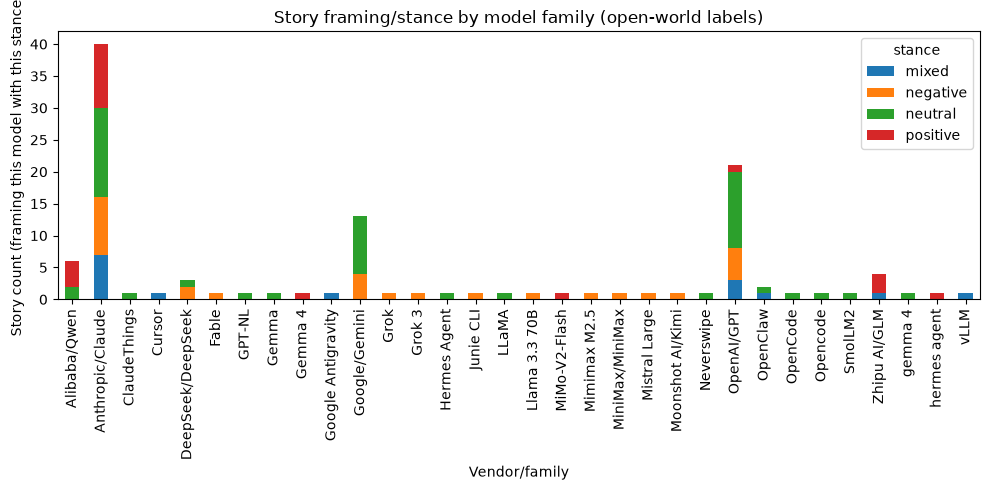

In [11]:
if not framing.empty:
    pivot = framing.pivot_table(
        index="group_label", columns="stance", values="story_count", fill_value=0
    )
    ax = pivot.plot(kind="bar", stacked=True, figsize=(10, 5))
    ax.set_ylabel("Story count (framing this model with this stance)")
    ax.set_xlabel("Vendor/family")
    ax.set_title("Story framing/stance by model family (open-world labels)")
    plt.tight_layout()
    plt.show()
else:
    print("No framed (stance-labeled) observations available.")

## 8. Fixed-seed 30-story review

A fixed-seed sample of 30 stories (`seed=20260714`) drawn from the latest successful extractions, including both title-only and self-post stories when both exist. The same seed always returns the same `story_id`s in the same order (see `tests/test_analysis.py::test_review_sample_is_reproducible`). Reviewer columns (`is_relevant`, `expected_mentions`, ...) start empty and match the header of `data/manual_review_template.csv` -- a human fills them in by hand.

In [12]:
from analysis import review_sample

REVIEW_SEED = 20260714
REVIEW_SAMPLE_SIZE = 30

review = review_sample(conn, sample_size=REVIEW_SAMPLE_SIZE, seed=REVIEW_SEED)
review

,story_id,title,normalized_text,parsed_json,is_relevant,expected_mentions,extracted_mentions,evidence_valid,family_version_mapping_valid,stance_valid,error_type,reviewer_notes
0,47877328,NY sues Coinbase and Gemini to halt unlicensed...,,"{""relevant"": false, ""observations"": [], ""exten...",None,None,None,None,None,None,None,None
1,48903199,Show HN: ZenStack – access control at the ORM ...,"Hi HN, I'm Jiasheng, co-creator of ZenStack. A...","{""relevant"": false, ""observations"": [], ""exten...",None,None,None,None,None,None,None,None
2,48903487,Show HN: Neverswipe – your AI agent dates so y...,,"{""relevant"": true, ""observations"": [{""surface""...",None,None,None,None,None,None,None,None
3,48689895,Neural Image Compression with Gemini 3,,"{""relevant"": true, ""observations"": [{""surface""...",None,None,None,None,None,None,None,None
4,47438423,"Show HN: Agentic Copilot – Bring Claude Code, ...",Obsidian plugin that connects to CLI agents yo...,"{""relevant"": true, ""observations"": [{""surface""...",None,None,None,None,None,None,None,None
5,47304412,Show HN: Tighten skill to read AI-generated co...,After repeatedly asking Claude Code to rewrite...,"{""relevant"": true, ""observations"": [{""surface""...",None,None,None,None,None,None,None,None
6,48559188,GPT‑NL: a sovereign language model for the Net...,,"{""relevant"": true, ""observations"": [{""surface""...",None,None,None,None,None,None,None,None
7,48736097,"Claude Sonnet 5 Could Be Released Later Today,...",,"{""relevant"": true, ""observations"": [{""surface""...",None,None,None,None,None,None,None,None
8,48450142,Apple reveals new AI architecture built around...,,"{""relevant"": true, ""observations"": [{""surface""...",None,None,None,None,None,None,None,None
9,47676736,I don't want an autonomous AI agent. I want a ...,"I’ve been using Cursor, Claude, and others qui...","{""relevant"": true, ""observations"": [{""surface""...",None,None,None,None,None,None,None,None


In [13]:
# Export for hand annotation. This is local reviewer working data (like
# ai_monitor.db) rather than the versioned template -- decide at review time
# whether the completed copy is worth committing.
review_export_path = "data/manual_review_sample.csv"
review.to_csv(review_export_path, index=False)
print(f"Wrote {len(review)} rows to {review_export_path} for manual annotation.")

Wrote 30 rows to data/manual_review_sample.csv for manual annotation.


## 9. Precision / recall / evidence-validity calculations

Once a reviewer hand-fills `expected_mentions` (ground-truth mention count per story) and `extracted_mentions` (how many of those the LLM correctly extracted, i.e. true positives) in a completed review CSV, this section computes:

- **recall** = sum(extracted_mentions) / sum(expected_mentions) -- the share of true mentions the extraction step found.
- **precision** = sum(extracted_mentions) / sum(LLM-produced, evidence-verified observations for the same stories) -- the share of the LLM's own output that was correct. The denominator is recomputed independently from `story_extractions.parsed_json` for the reviewed stories (same `evidence_verified` filter Gold uses), not taken from the CSV, so precision does not depend on the reviewer manually counting false positives.
- **evidence / mapping / stance validity rates** = mean of the corresponding yes/no reviewer columns.

This cell expects a completed copy of `data/manual_review_template.csv` (or `data/manual_review_sample.csv` from Section 8) with reviewer columns filled in; it reports what is available and does not fabricate missing labels.

In [14]:
import json
from pathlib import Path

# Prefer the Section-8 export when present, else fall back to the versioned template.
_sample_path = Path("data/manual_review_sample.csv")
_template_path = Path("data/manual_review_template.csv")
completed_review_path = _sample_path if _sample_path.exists() else _template_path
if not completed_review_path.exists():
    print(f"{completed_review_path} not found -- nothing to score yet.")
else:
    completed = pd.read_csv(completed_review_path)
    completed = completed.dropna(subset=["expected_mentions", "extracted_mentions"])
    if completed.empty:
        print("Manual review columns are not filled in yet -- nothing to score.")
    else:
        reviewed_ids = tuple(completed["story_id"])
        placeholders = ",".join("?" for _ in reviewed_ids)
        parsed = pd.read_sql_query(
            f"SELECT story_id, parsed_json FROM story_extractions "
            f"WHERE status = 'succeeded' AND story_id IN ({placeholders})",
            conn,
            params=reviewed_ids,
        )

        def _observation_count(raw_json: str) -> int:
            envelope = json.loads(raw_json)
            return sum(
                1 for obs in envelope.get("observations", [])
                if obs.get("evidence_verified") is True
            )

        parsed["llm_observation_count"] = parsed["parsed_json"].apply(_observation_count)
        llm_counts = parsed.groupby("story_id")["llm_observation_count"].sum()

        expected_total = completed["expected_mentions"].astype(float).sum()
        extracted_total = completed["extracted_mentions"].astype(float).sum()
        llm_total = completed["story_id"].map(llm_counts).fillna(0).sum()

        recall = extracted_total / expected_total if expected_total else float("nan")
        precision = extracted_total / llm_total if llm_total else float("nan")

        def _validity_rate(column: str) -> float:
            if column not in completed.columns:
                return float("nan")
            values = completed[column].astype(str).str.strip().str.lower()
            return values.isin(["y", "yes", "true", "1"]).mean()

        print(f"Reviewed stories with counts filled in: {len(completed)}")
        print(f"Recall (extracted/expected mentions): {recall:.2f}")
        print(f"Precision (extracted/LLM-produced observations): {precision:.2f}")
        print(f"Evidence validity rate: {_validity_rate('evidence_valid'):.2f}")
        print(f"Family/version mapping validity rate: {_validity_rate('family_version_mapping_valid'):.2f}")
        print(f"Stance validity rate: {_validity_rate('stance_valid'):.2f}")

Manual review columns are not filled in yet -- nothing to score.


## 10. Limitations and Phase 2

- **Collection coverage**: only stories matching the configured Algolia `BROAD_KEYWORDS`/`TRACKED_KEYWORDS` are collected, and collection runs are triggered manually (`collector.py --backfill N` / incremental runs) rather than on a continuous schedule -- gaps between runs are possible.
- **Two different denominators**: trend and co-occurrence (Sections 4-6) rest on every collected story via catalog alias matching; framing and the manual review (Sections 7-9) rest only on the far smaller extracted sample. Do not read a framing count as a share of the collection.
- **Catalog-bound recall**: the candidate path can only see model families present in the versioned catalog. Surfaces outside it (Grok, Mistral, Llama, Gemma, ...) stay `unresolved` and never reach a family figure, so a family's absence here means "not catalogued", not "not discussed".
- **Alias precision**: matching is lexical, so a name that is not the model still matches -- the Gemini crypto exchange is a real example in this data. The extraction step catches these (`relevant: false`), but the candidate path alone does not, which inflates candidate counts relative to extraction-verified ones.
- **Engagement vs. sentiment**: `points`/`num_comments` shown alongside trend figures are Hacker News engagement counts only. They are never used as, or relabeled to, a sentiment/opinion signal; the only tone signal in this notebook is the open-world `stance` field from `model_framing_sentiment`, which describes how a *story* frames a model, not how HN commenters feel or how many viewed it.
- **Extraction noise**: a single session-authored extraction (`config.SESSION_EXTRACTION_MODEL`) and prompt version per story; only evidence-verified observations feed Gold, and only a fixed 30-story sample is manually reviewed for precision/recall/evidence validity, not the full dataset.
- **Reference data**: model release dates and benchmark scores are limited to what `reference_data.py`/`data/model_catalog.json` currently source; unlisted or unresolved surfaces stay `unresolved` rather than being force-matched.
- **Out of scope for this MVP** (explicit Phase 2 per `docs/superpowers/specs/2026-07-14-ai-pulse-design.md`): Reddit or other platforms, HN comment text, Supabase, a formal ontology, a hosted MCP server, and automated/scheduled collection.